# Colab C — PyTorch Class-Based: 3-Layer Deep NN (Built-in Modules)

**CMPE 258 — Deep Learning | Spring 2026 | San José State University**

**Author:** Parth  
**Instructor:** Vijay Eranti

---

## Overview

This notebook uses **PyTorch's built-in `nn.Module`** classes to implement the same 3-hidden-layer network:
- `nn.Linear` for fully connected layers
- `nn.ReLU`, `nn.Tanh` for activations
- `nn.MSELoss` for loss
- `torch.optim.Adam` for optimization
- Proper `model.train()` / `model.eval()` discipline

### Architecture
```
Input(3) → Linear(64)+ReLU → Linear(32)+Tanh → Linear(16)+ReLU → Linear(1)
```

## 1. Environment Setup

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}  |  Device: {device}')

PyTorch: 2.10.0+cu128  |  Device: cuda


## 2. Synthetic Data

In [2]:
n_samples = 500
X_np = np.random.uniform(-1, 1, (n_samples, 3))
x1, x2, x3 = X_np[:, 0:1], X_np[:, 1:2], X_np[:, 2:3]

y_np = (3.0 * x1**2
        + 2.0 * np.sin(np.pi * x2) * x3
        - x3**3
        + 0.5 * x1 * x2
        + 1.0)

X_tensor = torch.tensor(X_np, dtype=torch.float32, device=device)
y_tensor = torch.tensor(y_np, dtype=torch.float32, device=device)

print(f'X: {X_tensor.shape}  |  y: {y_tensor.shape}')

X: torch.Size([500, 3])  |  y: torch.Size([500, 1])


## 3. Model Definition (nn.Module)

Clean class-based architecture using PyTorch idioms: `nn.Sequential`, weight initialization, and `forward()` method.

In [3]:
class DeepNet3Layer(nn.Module):
    """
    3-Hidden-Layer Deep Neural Network using PyTorch built-in modules.

    Architecture:
      Input(3) → Linear(64)+ReLU → Linear(32)+Tanh → Linear(16)+ReLU → Linear(1)
    """

    def __init__(self, input_dim=3, h1=64, h2=32, h3=16):
        super().__init__()
        self.network = nn.Sequential(
            # Hidden layer 1
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            # Hidden layer 2
            nn.Linear(h1, h2),
            nn.Tanh(),
            # Hidden layer 3
            nn.Linear(h2, h3),
            nn.ReLU(),
            # Output layer
            nn.Linear(h3, 1)
        )
        self._init_weights()

    def _init_weights(self):
        """Apply He initialization to all linear layers."""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.network(x)


model = DeepNet3Layer().to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {total_params:,}')

DeepNet3Layer(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)

Total parameters: 2,881


## 4. Training

Using `nn.MSELoss` and `Adam` optimizer with proper training discipline.

In [4]:
# --- Training ---
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

num_epochs = 1500
loss_history = []

model.train()
for epoch in range(num_epochs):
    # Forward
    y_pred = model(X_tensor)
    loss = criterion(y_pred, y_tensor)
    loss_history.append(loss.item())

    # Backward + update
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 200 == 0 or epoch == num_epochs - 1:
        print(f'Epoch {epoch:4d}/{num_epochs}  |  Loss: {loss.item():.6f}')

print(f'\nFinal Loss: {loss_history[-1]:.6f}')

Epoch    0/1500  |  Loss: 6.934449
Epoch  200/1500  |  Loss: 0.055361
Epoch  400/1500  |  Loss: 0.011886
Epoch  600/1500  |  Loss: 0.004335
Epoch  800/1500  |  Loss: 0.002509
Epoch 1000/1500  |  Loss: 0.002629
Epoch 1200/1500  |  Loss: 0.001601
Epoch 1400/1500  |  Loss: 0.002228
Epoch 1499/1500  |  Loss: 0.001097

Final Loss: 0.001097


## 5. Results

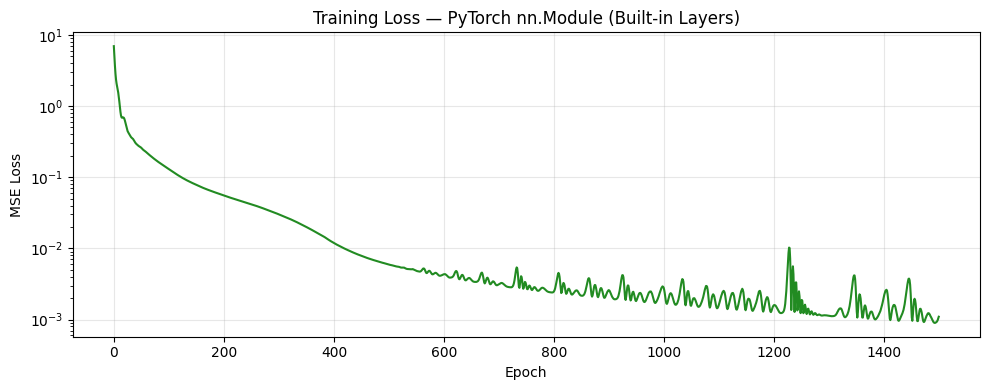

In [5]:
# --- Loss Curve ---
plt.figure(figsize=(10, 4))
plt.plot(loss_history, linewidth=1.5, color='forestgreen')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Training Loss — PyTorch nn.Module (Built-in Layers)')
plt.grid(True, alpha=0.3); plt.yscale('log')
plt.tight_layout()
plt.show()

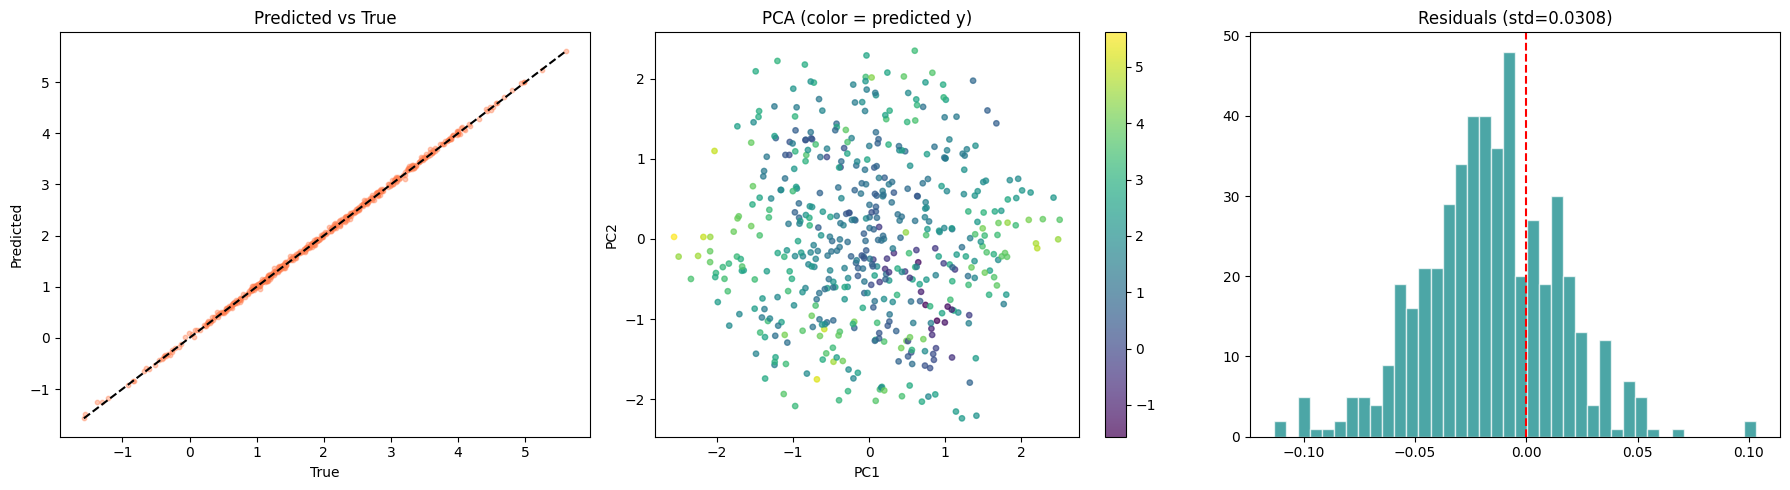

R² score: 0.9992


In [6]:
# --- Evaluation ---
model.eval()
with torch.no_grad():
    y_final = model(X_tensor).cpu().numpy()

y_true_np = y_tensor.cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Predicted vs True
axes[0].scatter(y_true_np, y_final, alpha=0.4, s=10, color='coral')
lims = [y_true_np.min(), y_true_np.max()]
axes[0].plot(lims, lims, 'k--', lw=1.5)
axes[0].set_xlabel('True'); axes[0].set_ylabel('Predicted')
axes[0].set_title('Predicted vs True')

# PCA visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(StandardScaler().fit_transform(X_np))
sc = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_final.flatten(),
                     cmap='viridis', alpha=0.7, s=15)
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].set_title('PCA (color = predicted y)')
plt.colorbar(sc, ax=axes[1])

# Residuals
residuals = (y_true_np - y_final).flatten()
axes[2].hist(residuals, bins=40, color='teal', alpha=0.7, edgecolor='white')
axes[2].axvline(0, color='red', linestyle='--')
axes[2].set_title(f'Residuals (std={residuals.std():.4f})')

plt.tight_layout()
plt.show()

# R²
ss_res = np.sum((y_true_np - y_final)**2)
ss_tot = np.sum((y_true_np - y_true_np.mean())**2)
print(f'R² score: {1 - ss_res/ss_tot:.4f}')

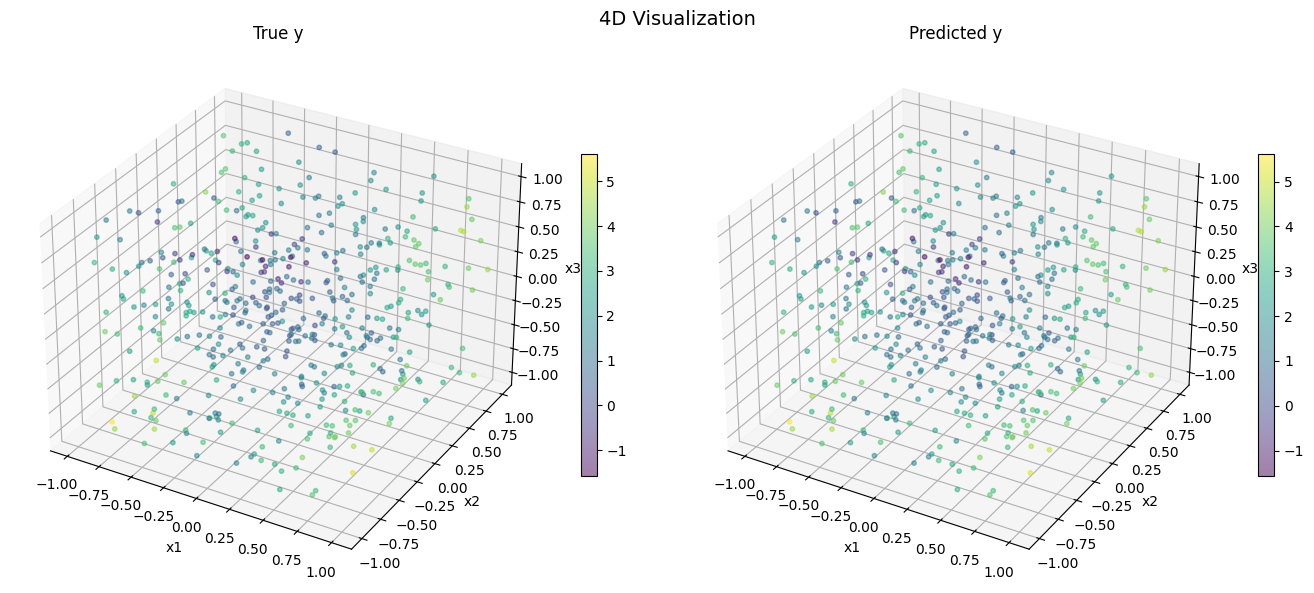

In [7]:
# --- 4D Plot ---
fig = plt.figure(figsize=(14, 6))
for i, (data, title) in enumerate([(y_true_np, 'True y'), (y_final, 'Predicted y')]):
    ax = fig.add_subplot(1, 2, i+1, projection='3d')
    sc = ax.scatter(X_np[:, 0], X_np[:, 1], X_np[:, 2],
                    c=data.flatten(), cmap='viridis', alpha=0.5, s=10)
    ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_zlabel('x3')
    ax.set_title(title)
    plt.colorbar(sc, ax=ax, shrink=0.6)
plt.suptitle('4D Visualization', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Summary

| Component | Implementation |
|-----------|---------------|
| Model class | `nn.Module` with `nn.Sequential` |
| Layers | `nn.Linear` (built-in) |
| Activations | `nn.ReLU`, `nn.Tanh` |
| Loss | `nn.MSELoss` |
| Optimizer | `torch.optim.Adam` |
| Init | `nn.init.kaiming_normal_` (He init) |

Compare with **Colab B** (same architecture, all done manually) to see the power of PyTorch's abstractions.